"Kaggle üzerinden alınan Pima Indians Diabetes veri seti üzerinde Keşifsel Veri Analizi (EDA) ve çeşitli Sınıflandırma (Classification) modellerinin hiperparametre optimizasyonu ile karşılaştırılması."

In [109]:
import numpy as np
import pandas as pd
import seaborn  as sns
import matplotlib.pyplot as plt

In [110]:
data = pd.read_csv("16-diabetes.csv")

In [111]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## EDA SÜRECİ

In [112]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [113]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [114]:
data.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


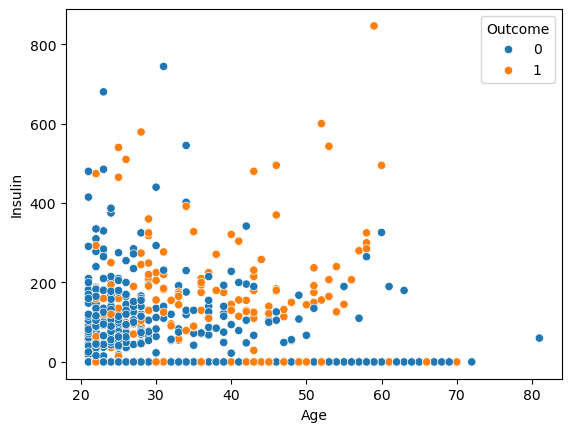

In [115]:
sns.scatterplot(x=data["Age"],y=data["Insulin"],hue=data["Outcome"])
plt.show()

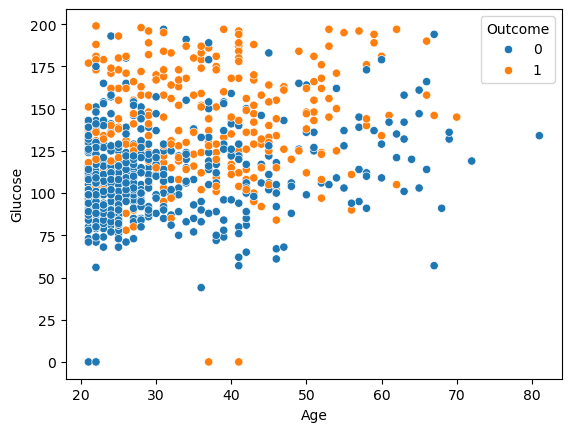

In [116]:
sns.scatterplot(x=data["Age"],y=data["Glucose"],hue=data["Outcome"])
plt.show()

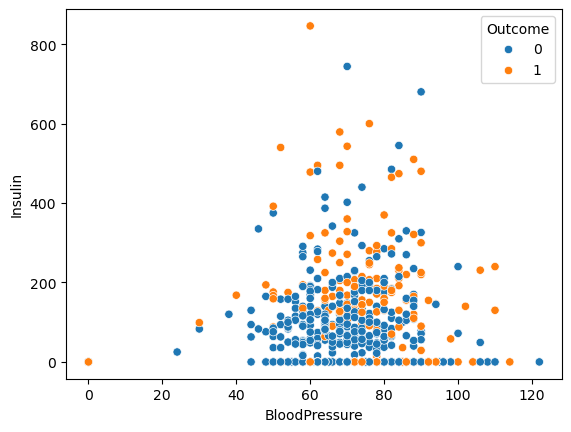

In [117]:
sns.scatterplot(x=data["BloodPressure"],y=data["Insulin"],hue=data["Outcome"])
plt.show()

In [118]:
# Outcome ile diğer bağımsız girdiler kıyas alındığında yüksek bir korelasyon ilişkisi göremedim.

In [119]:
data["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [120]:
# Dengeli bir sınıflandırma

In [121]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [122]:
# Verinin genel bilgilerine bakıldığında bazı yanlışlıklar görüyoruz. Bir insanda kan basıncı, insülin gibi değerlerin 0 olması mümkün değil.

In [123]:
# Muhtemelen boş veriler 0 olarak girilmiş.

In [124]:
zero_data = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

In [125]:
for col in zero_data:
    print((data[col] == 0).sum())

5
35
227
374
11


In [126]:
# Bazı kolonlorda neredeyse verinin yarısı boş.

In [127]:
# Yarısı veya daha fazlası boş olanları silip, kalan kolonları medyan ile doldurmayı deneyeceğim

In [128]:
data = data.drop("Insulin",axis=1)

In [129]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,33.6,0.627,50,1
1,1,85,66,29,26.6,0.351,31,0
2,8,183,64,0,23.3,0.672,32,1
3,1,89,66,23,28.1,0.167,21,0
4,0,137,40,35,43.1,2.288,33,1


In [130]:
zero_data = ["Glucose","BloodPressure","SkinThickness","BMI"]

In [131]:
# Data Leakuge önlemek adına veriyi X,y olarak ayıralım.

In [132]:
from sklearn.model_selection import train_test_split

In [133]:
X = data.drop("Outcome",axis=1)
y = data["Outcome"]

In [134]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   BMI                       768 non-null    float64
 5   DiabetesPedigreeFunction  768 non-null    float64
 6   Age                       768 non-null    int64  
 7   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 48.1 KB


In [135]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=15)

In [136]:
for col in zero_data:
    median = X_train[col].median()
    X_train[col] = X_train[col].replace(0,np.nan)
    X_test[col] = X_test[col].replace(0,np.nan)
    X_train[col] = X_train[col].fillna(median)
    X_test[col] = X_test[col].fillna(median)

In [137]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 576 entries, 548 to 456
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               576 non-null    int64  
 1   Glucose                   576 non-null    float64
 2   BloodPressure             576 non-null    float64
 3   SkinThickness             576 non-null    float64
 4   BMI                       576 non-null    float64
 5   DiabetesPedigreeFunction  576 non-null    float64
 6   Age                       576 non-null    int64  
dtypes: float64(5), int64(2)
memory usage: 36.0 KB


In [138]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 192 entries, 343 to 687
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               192 non-null    int64  
 1   Glucose                   192 non-null    int64  
 2   BloodPressure             192 non-null    float64
 3   SkinThickness             192 non-null    float64
 4   BMI                       192 non-null    float64
 5   DiabetesPedigreeFunction  192 non-null    float64
 6   Age                       192 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 12.0 KB


In [139]:
# Yukarıdaki işlemde 0 geçen verileri önce nan'a çevirdik ardından düzeni korumak adına medyan ile doldurduk.

In [140]:
# Scale İşlemi

In [141]:
from sklearn.preprocessing import StandardScaler

In [142]:
scaler = StandardScaler()

In [143]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Sınıflandırma Eğitimi ve Model Kıyası

In [147]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

In [148]:
models = {
    "Logistic" : LogisticRegression(),
    "SVC" : SVC(),
    "KNN" : KNeighborsClassifier(),
    "Tree" : DecisionTreeClassifier(),
    "RandomForest" : RandomForestClassifier(),
    "AdaBoost" : AdaBoostClassifier()
}

In [150]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [152]:
for model in models.values() : 
    model.fit(X_train_scaled,y_train)
    y_pred = model.predict(X_test_scaled)
    print(classification_report(y_test,y_pred))
    print(confusion_matrix(y_test,y_pred))
    print(accuracy_score(y_test,y_pred))

    print("---------------------------")
    print("\n")

              precision    recall  f1-score   support

           0       0.80      0.86      0.83       129
           1       0.66      0.56      0.60        63

    accuracy                           0.76       192
   macro avg       0.73      0.71      0.72       192
weighted avg       0.75      0.76      0.75       192

[[111  18]
 [ 28  35]]
0.7604166666666666
---------------------------


              precision    recall  f1-score   support

           0       0.75      0.83      0.79       129
           1       0.56      0.44      0.50        63

    accuracy                           0.70       192
   macro avg       0.66      0.64      0.64       192
weighted avg       0.69      0.70      0.69       192

[[107  22]
 [ 35  28]]
0.703125
---------------------------


              precision    recall  f1-score   support

           0       0.78      0.81      0.79       129
           1       0.57      0.52      0.55        63

    accuracy                           0.71     

In [154]:
# Sırasıyla yapılan model karşılaştırmasında ortalama %70lik başarı elde ettim.

In [155]:
# En yüksek sonuç verenlerde hyperparameter tuning işlemi yaparak biraz daha yükseltmeye çalışacağım.

## HyperParameter Tuning

In [158]:
high_score_models = {
    "Logistic" : LogisticRegression(),
    "KNN" : KNeighborsClassifier(),
    "RandomForest" : RandomForestClassifier(),
    "AdaBoost" : AdaBoostClassifier()
}

In [160]:
param_grids = {
    "Logistic": {
        "C": [0.1, 1, 10],
        "penalty": ["l2"]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 9],
        "weights": ["uniform", "distance"]
    },
    "RandomForest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5]
    },
    "AdaBoost": {
        "n_estimators": [50, 100, 150],
        "learning_rate": [0.01, 0.1, 1.0]
    }
}

In [159]:
from sklearn.model_selection import GridSearchCV

In [162]:
for name,model in high_score_models.items() :
    print(f"{name} için grid işlemi")
    params = param_grids[name]
    grid = GridSearchCV(estimator=model,param_grid=params,cv=5,scoring="accuracy",n_jobs=-1)
    grid.fit(X_train_scaled,y_train)

    y_pred = grid.predict(X_test_scaled)
    print(classification_report(y_test,y_pred))
    print(confusion_matrix(y_test,y_pred))
    print(accuracy_score(y_test,y_pred))

    print("---------------------------")
    print("\n")

    

Logistic için grid işlemi
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       129
           1       0.66      0.56      0.60        63

    accuracy                           0.76       192
   macro avg       0.73      0.71      0.72       192
weighted avg       0.75      0.76      0.75       192

[[111  18]
 [ 28  35]]
0.7604166666666666
---------------------------


KNN için grid işlemi
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       129
           1       0.63      0.52      0.57        63

    accuracy                           0.74       192
   macro avg       0.71      0.69      0.70       192
weighted avg       0.74      0.74      0.74       192

[[110  19]
 [ 30  33]]
0.7447916666666666
---------------------------


RandomForest için grid işlemi
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       129
           1    

In [164]:
# Çok bir değişim olmadı fakat az da olsa grid işlemi ile artış gördük.